# Business Overview Dashboard

## Setup

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

sns.set_style("whitegrid")

#Load data
customer_df = pd.read_csv("../data/derived/customer_fact_table.csv")
order_df = pd.read_csv("../data/derived/order_fact_table.csv")
inventory_df = pd.read_csv("../data/derived/product_month_inventory_fact.csv")

## Convert Date Columns

In [41]:
customer_df["signup_date"] = pd.to_datetime(customer_df["signup_date"])
order_df["order_date"] = pd.to_datetime(order_df["order_date"])
inventory_df["snapshot_month"] = pd.to_datetime(inventory_df["snapshot_month"])

## Monthly Summary Tables

In [42]:
# 1. Monthly Signups
monthly_signups = customer_df.groupby(
    customer_df["signup_date"].dt.to_period("M")
).size().reset_index(name="signups")

monthly_signups["signup_date"] = monthly_signups["signup_date"].astype(str)

# 2. Monthly Orders
monthly_orders = order_df.groupby(
    order_df["order_date"].dt.to_period("M")
).size().reset_index(name="orders")

monthly_orders["order_date"] = monthly_orders["order_date"].astype(str)

# 3. Monthly Sales
monthly_sales = order_df.groupby(
    order_df["order_date"].dt.to_period("M")
)["net_revenue"].sum().reset_index()

monthly_sales["order_date"] = monthly_sales["order_date"].astype(str)

# 4. Monthly Stockout Prevalence
monthly_stockout = inventory_df.groupby(
    inventory_df["snapshot_month"].dt.to_period("M")
)["stockout_flag"].mean().reset_index()

monthly_stockout["snapshot_month"] = monthly_stockout["snapshot_month"].astype(str)

## Plot Overview Dashboard

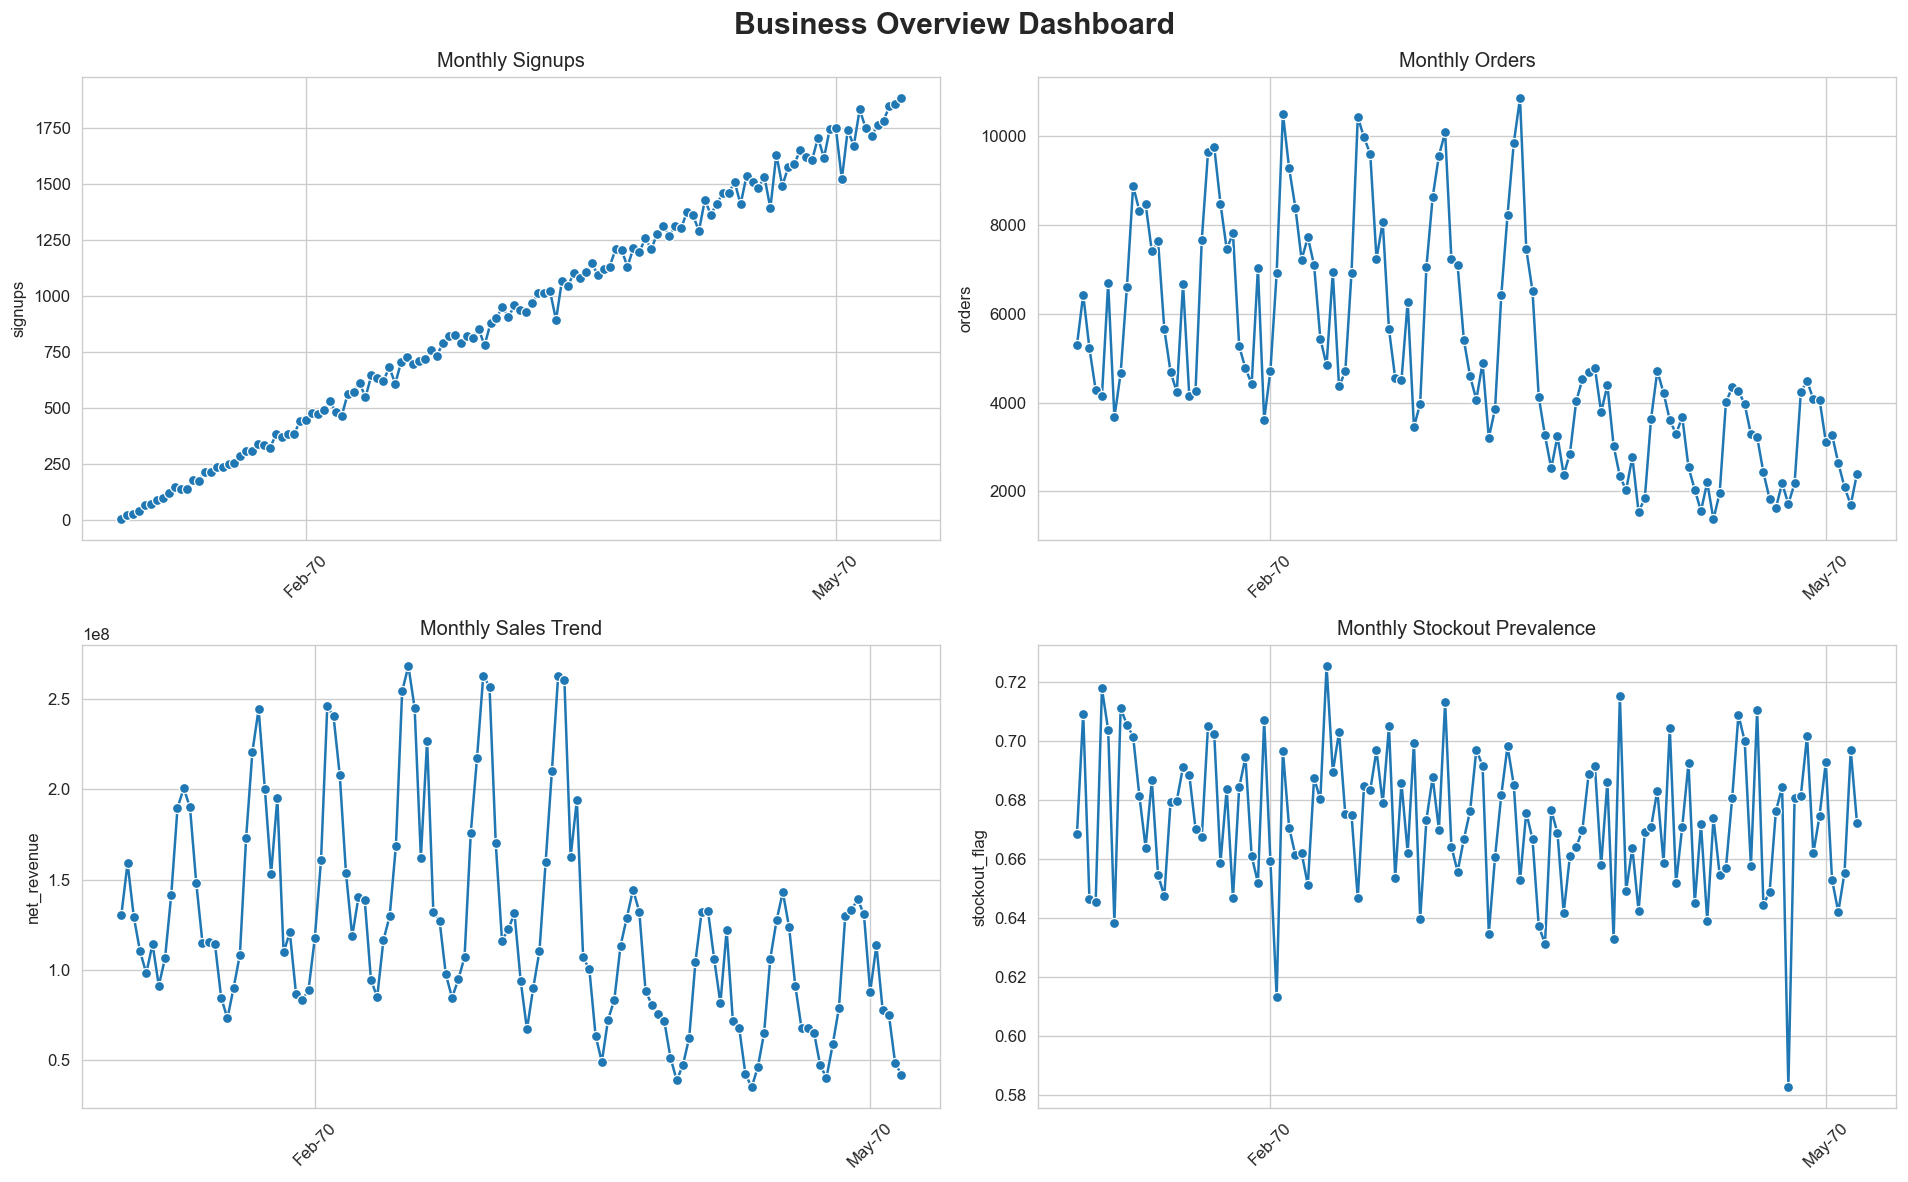

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))
fig.suptitle("Business Overview Dashboard", fontsize=18, weight="bold")

# Chart 1: Monthly Signups
sns.lineplot(
    data=monthly_signups,
    x="signup_date",
    y="signups",
    marker="o",
    ax=axes[0,0]
)
axes[0,0].set_title("Monthly Signups")

# Chart 2: Monthly Orders
sns.lineplot(
    data=monthly_orders,
    x="order_date",
    y="orders",
    marker="o",
    ax=axes[0,1]
)
axes[0,1].set_title("Monthly Orders")

# Chart 3: Monthly Sales
sns.lineplot(
    data=monthly_sales,
    x="order_date",
    y="net_revenue",
    marker="o",
    ax=axes[1,0]
)
axes[1,0].set_title("Monthly Sales Trend")

# Chart 4: Monthly Stockout
sns.lineplot(
    data=monthly_stockout,
    x="snapshot_month",
    y="stockout_flag",
    marker="o",
    ax=axes[1,1]
)
axes[1,1].set_title("Monthly Stockout Prevalence")

# TRỤC X (mỗi 3 tháng) 
for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

## Business Overview Insights

### 1. Monthly Signups
Số lượng người đăng ký tăng đều và khá ổn định theo thời gian, không có dấu hiệu suy giảm.
=> Hoạt động thu hút khách hàng đang vận hành hiệu quả và duy trì tốt. Tuy nhiên, tốc độ tăng trưởng mang tính tuyến tính cho thấy doanh nghiệp chưa tạo được cú hích tăng trưởng mạnh từ các chiến dịch lớn.

Đề xuất:
- Thử nghiệm chương trình giới thiệu bạn bè (referral program) hoặc chiến dịch theo mùa  
- Tăng đầu tư vào các kênh có hiệu quả tốt  
- Theo dõi tỷ lệ chuyển đổi từ đăng ký sang đơn hàng đầu tiên

### 2. Monthly Orders
Số lượng đơn hàng biến động mạnh và không tăng tương ứng với tốc độ tăng của người đăng ký, ở cuối kỳ tốc độ có xu hướng giảm.
=> Doanh nghiệp đang gặp vấn đề ở giai đoạn kích hoạt/chuyển đổi. Nhiều người dùng đăng ký nhưng không phát sinh mua hàng.

Đề xuất: 
- Tối ưu trải nghiệm onboarding cho khách hàng mới  
- Triển khai ưu đãi cho đơn hàng đầu tiên  
- Phân tích cohort để đo lường tỷ lệ chuyển đổi của từng nhóm khách hàng

### 3. Monthly Sales Trend
Doanh thu dao động lớn giữa các tháng, xuất hiện nhiều đợt tăng ngắn hạn nhưng thiếu ổn định. Cuối kỳ giảm nhẹ.
=> Doanh thu hiện phụ thuộc vào các chiến dịch ngắn hạn (promotion/campaign), chưa hình thành nguồn doanh thu lặp lại bền vững.

Đề xuất:  
- Tăng tỷ lệ mua lại 
- Xây dựng chương trình khách hàng thân thiết / thành viên  
- Đánh giá hiệu quả ROI của các chương trình khuyến mãi

### 4. Monthly Stockout Prevalence
Tỷ lệ hết hàng duy trì ở mức cao và chưa có cải thiện rõ ràng.
=> Đang bị một điểm nghẽn về vận hành ở chuỗi cung ứng. Doanh nghiệp có khả năng đang mất doanh thu do không đủ hàng để đáp ứng nhu cầu thị trường.

Đề xuất:
- Cải thiện dự báo nhu cầu   
- Đồng bộ kế hoạch tồn kho với xu hướng traffic và doanh số  
- Ưu tiên bổ sung hàng cho các sản phẩm có nhu cầu cao


Doanh nghiệp đang tăng trưởng tốt ở việc thu hút được nhiều người đăng ký mới, nhưng tỷ lệ chuyển đổi yếu và tình trạng hết hàng kéo dài đang hạn chế khả năng tạo doanh thu thực tế. Để có thể tăng trưởng bền vững, doanh nghiệp cần đồng thời tập trung vào việc kích hoạt khách hàng mới và cải thiện khả năng đáp ứng tồn kho cho khách hàng cũ.

# Chart 8 - Fill Rate vs Demand by Category

## Setup

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12,7)
plt.rcParams["figure.dpi"] = 120

## Load Data

In [45]:
df = pd.read_csv("../data/derived/product_month_inventory_fact.csv")
df.head()

,product_id,snapshot_date,snapshot_month,year,month,product_name,category,segment,stock_on_hand,units_received,...,net_units_change,available_units,stockout_days,stockout_rate_days,days_of_supply,fill_rate,sell_through_rate,stockout_flag,overstock_flag,reorder_flag
0,1,2022-10-31,2022-10-01,2022,10,DragonWear MA-01,Casual,All-weather,3,1,...,0,4,2,0.064516,90.0,0.9333,0.2500,1,0,0
1,1,2022-11-30,2022-11-01,2022,11,DragonWear MA-01,Casual,All-weather,3,1,...,0,4,1,0.033333,90.0,0.9667,0.2500,1,0,0
2,1,2022-12-31,2022-12-01,2022,12,DragonWear MA-01,Casual,All-weather,3,1,...,0,4,1,0.032258,90.0,0.9667,0.2500,1,0,0
3,3,2016-04-30,2016-04-01,2016,4,DragonWear MA-03,Casual,All-weather,35,13,...,2,46,2,0.066667,95.5,0.9333,0.2391,1,1,0
4,3,2016-05-31,2016-05-01,2016,5,DragonWear MA-03,Casual,All-weather,36,11,...,1,46,1,0.032258,108.0,0.9667,0.2174,1,1,0


## Prepare Chart Data

In [46]:
chart_df = df.groupby("category", as_index=False).agg(
    total_units_sold=("units_sold", "sum"),
    avg_fill_rate=("fill_rate", "mean"),
    avg_stockout_days=("stockout_days", "mean")
)

chart_df

,category,total_units_sold,avg_fill_rate,avg_stockout_days
0,Casual,31202,0.961823,1.145304
1,GenZ,48695,0.961718,1.148481
2,Outdoor,337510,0.962705,1.118860
3,Streetwear,511467,0.960248,1.192553


## Create Scatter Plot

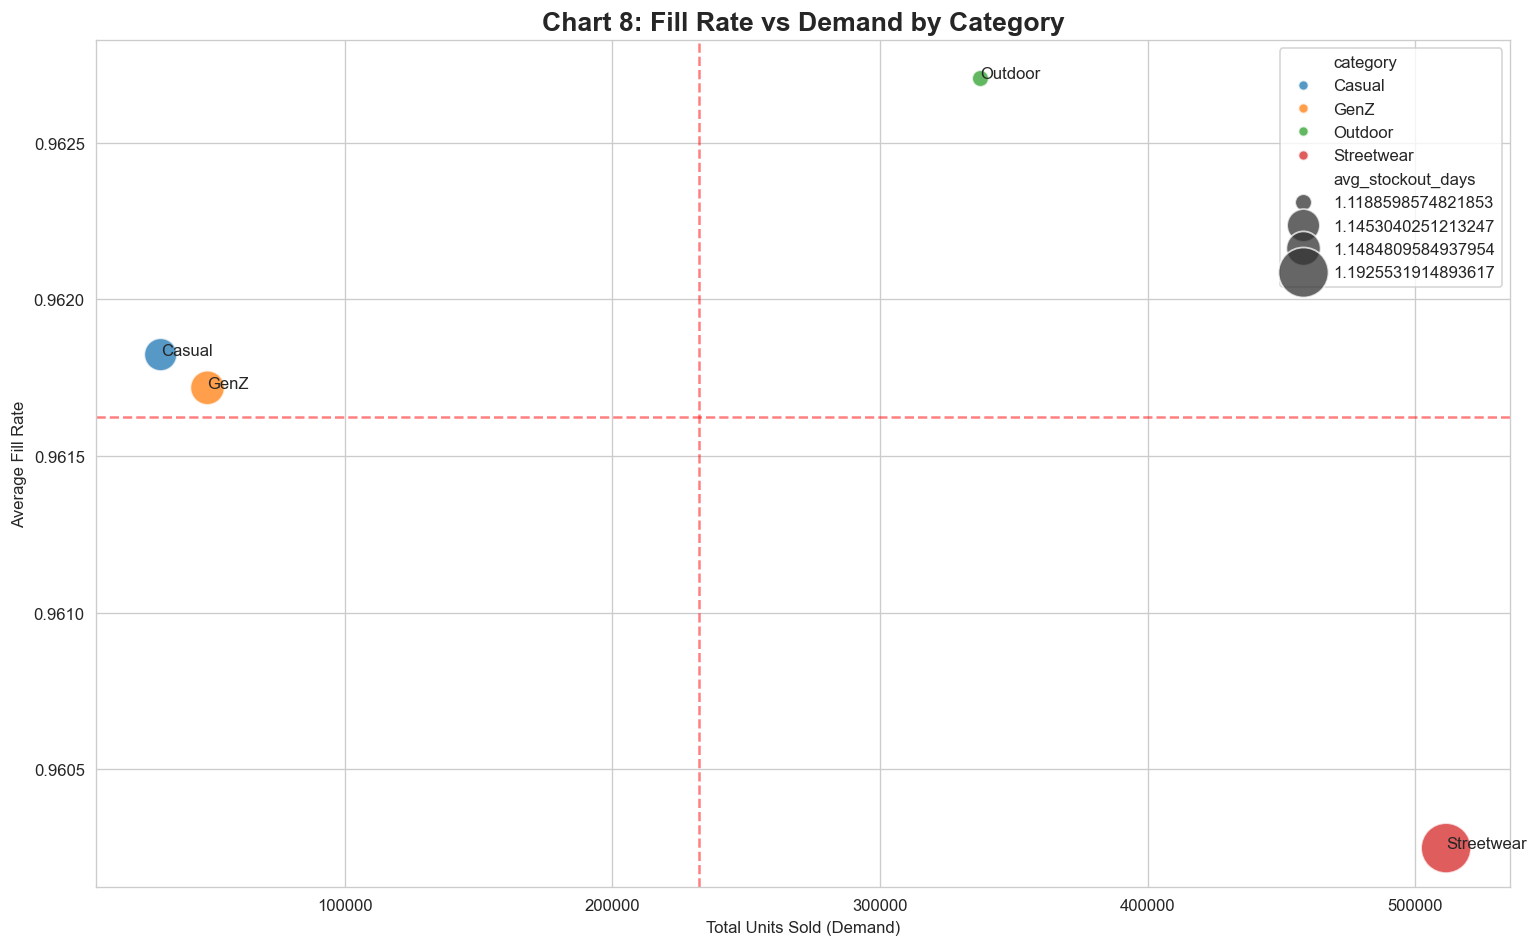

In [47]:
# Style
sns.set_style("whitegrid")
plt.figure(figsize=(13,8))

# Scatter
sns.scatterplot(
    data=chart_df,
    x="total_units_sold",
    y="avg_fill_rate",
    size="avg_stockout_days",
    hue="category",
    sizes=(100, 900),
    alpha=0.75
)

# Label each point
for i in range(len(chart_df)):
    plt.text(
        chart_df["total_units_sold"][i] + 3,
        chart_df["avg_fill_rate"][i],
        chart_df["category"][i],
        fontsize=10
    )

# Mean lines
plt.axvline(chart_df["total_units_sold"].mean(), linestyle="--", color="red", alpha=0.5)
plt.axhline(chart_df["avg_fill_rate"].mean(), linestyle="--", color="red", alpha=0.5)

# Titles
plt.title("Chart 8: Fill Rate vs Demand by Category", fontsize=16, weight="bold")
plt.xlabel("Total Units Sold (Demand)")
plt.ylabel("Average Fill Rate")
plt.tight_layout()
plt.show()

## Các phát hiện chính + Insight

1. Streetwear là danh mục có mức độ rủi ro cao nhất. 
Danh mục này có nhu cầu cao nhất (số lượng bán ra lớn nhất) nhưng lại có tỷ lệ đáp ứng thấp nhất trong tất cả các nhóm sản phẩm.  
Điều này cho thấy nhu cầu khách hàng chưa được đáp ứng đầy đủ, tình trạng thiếu hàng xảy ra thường xuyên và có nguy cơ thất thoát doanh thu.

2. Outdoor là danh mục có hiệu quả vận hành tốt nhất. 
Danh mục này vừa có nhu cầu cao vừa đạt tỷ lệ đáp ứng cao nhất, cho thấy hoạt động lập kế hoạch tồn kho và bổ sung hàng hóa đang được thực hiện hiệu quả.

3. Casual và GenZ có nhu cầu thấp hơn nhưng tỷ lệ đáp ứng ở mức chấp nhận được.  
Điều này cho thấy mức độ phục vụ tồn kho hiện tại là đủ, tuy nhiên cơ hội tăng trưởng doanh thu có thể phụ thuộc nhiều hơn vào hoạt động marketing thay vì mở rộng nguồn cung.

=> BUSINESS ACTION
- Ưu tiên bổ sung hàng hóa và dự báo nhu cầu cho Streetwear
- Sử dụng Outdoor làm chuẩn tham chiếu cho kế hoạch cung ứng
- Đánh giá lại việc phân bổ tồn kho cho các danh mục có nhu cầu thấp
- Cải thiện fill rate ở các nhóm có nhu cầu cao để tận dụng doanh thu bị bỏ lỡ

Biểu đồ cho thấy hiệu quả tồn kho hiện chưa được phân bổ tương xứng với nhu cầu thị trường. Cơ hội tăng trưởng lớn nhất nằm ở việc cải thiện khả năng đáp ứng đơn hàng của Streetwear, nơi nhu cầu đã có sẵn nhưng chưa được phục vụ đầy đủ.